In [39]:
#This notebook is about random forest for regression.

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [40]:
df=pd.read_csv("gym_crowdedness.csv")
df.head(10)

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
0,37,2015-08-14 17:00:11-07:00,61211,4,0,0,71.76,0,0,8,17
1,45,2015-08-14 17:20:14-07:00,62414,4,0,0,71.76,0,0,8,17
2,40,2015-08-14 17:30:15-07:00,63015,4,0,0,71.76,0,0,8,17
3,44,2015-08-14 17:40:16-07:00,63616,4,0,0,71.76,0,0,8,17
4,45,2015-08-14 17:50:17-07:00,64217,4,0,0,71.76,0,0,8,17
5,46,2015-08-14 18:00:18-07:00,64818,4,0,0,72.15,0,0,8,18
6,43,2015-08-14 18:20:08-07:00,66008,4,0,0,72.15,0,0,8,18
7,53,2015-08-14 18:30:09-07:00,66609,4,0,0,72.15,0,0,8,18
8,54,2015-08-14 18:40:14-07:00,67214,4,0,0,72.15,0,0,8,18
9,43,2015-08-14 18:50:15-07:00,67815,4,0,0,72.15,0,0,8,18


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62184 entries, 0 to 62183
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   number_people         62184 non-null  int64  
 1   date                  62184 non-null  object 
 2   timestamp             62184 non-null  int64  
 3   day_of_week           62184 non-null  int64  
 4   is_weekend            62184 non-null  int64  
 5   is_holiday            62184 non-null  int64  
 6   temperature           62184 non-null  float64
 7   is_start_of_semester  62184 non-null  int64  
 8   is_during_semester    62184 non-null  int64  
 9   month                 62184 non-null  int64  
 10  hour                  62184 non-null  int64  
dtypes: float64(1), int64(9), object(1)
memory usage: 5.2+ MB


In [42]:
df.columns

Index(['number_people', 'date', 'timestamp', 'day_of_week', 'is_weekend',
       'is_holiday', 'temperature', 'is_start_of_semester',
       'is_during_semester', 'month', 'hour'],
      dtype='object')

In [43]:
df.shape

(62184, 11)

In [44]:
df.describe()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour
count,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000,62184.000000
mean,29.072543,45799.437958,2.982504,0.282870,0.002573,58.557108,0.078831,0.660218,7.439824,12.236460
std,22.689026,24211.275891,1.996825,0.450398,0.050660,6.316396,0.269476,0.473639,3.445069,6.717631
min,0.000000,0.000000,0.000000,0.000000,0.000000,38.140000,0.000000,0.000000,1.000000,0.000000
25%,9.000000,26624.000000,1.000000,0.000000,0.000000,55.000000,0.000000,0.000000,5.000000,7.000000
50%,28.000000,46522.500000,3.000000,0.000000,0.000000,58.340000,0.000000,1.000000,8.000000,12.000000
75%,43.000000,66612.000000,5.000000,1.000000,0.000000,62.280000,0.000000,1.000000,10.000000,18.000000
max,145.000000,86399.000000,6.000000,1.000000,1.000000,87.170000,1.000000,1.000000,12.000000,23.000000


In [45]:
df['date']= pd.to_datetime(df["date"],utc= True)
df['year'] = df['date'].dt.year

In [46]:
df.head(3)

,number_people,date,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,2015-08-15 00:00:11+00:00,61211,4,0,0,71.76,0,0,8,17,2015
1,45,2015-08-15 00:20:14+00:00,62414,4,0,0,71.76,0,0,8,17,2015
2,40,2015-08-15 00:30:15+00:00,63015,4,0,0,71.76,0,0,8,17,2015


In [47]:
df['year'].unique()    

array([2015, 2016, 2017], dtype=int32)

In [48]:
df.drop(['date'], axis=1, inplace=True)

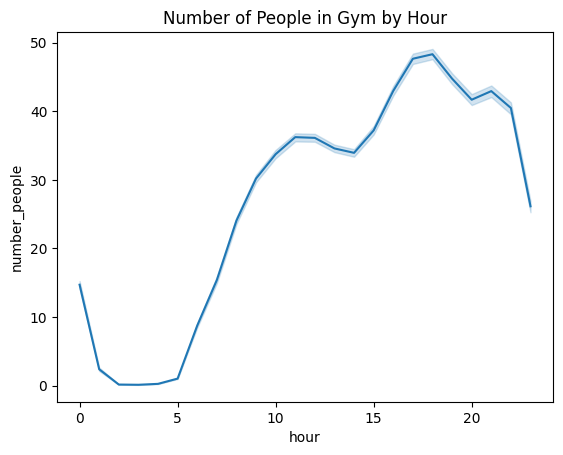

In [49]:
sns.lineplot(data=df, x="hour", y="number_people")
plt.title("Number of People in Gym by Hour")
plt.show()

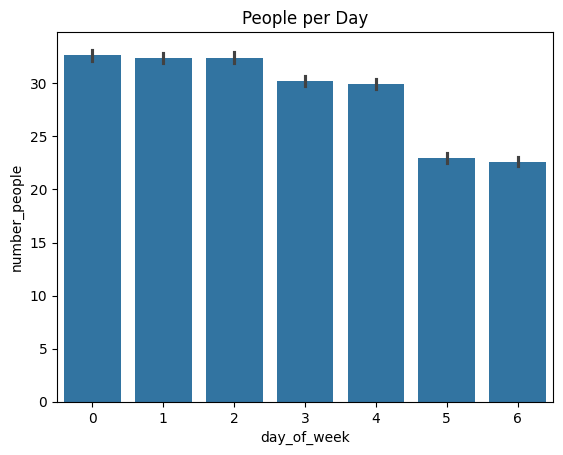

In [50]:
sns.barplot(data=df, x="day_of_week", y="number_people")
plt.title("People per Day")
plt.show()

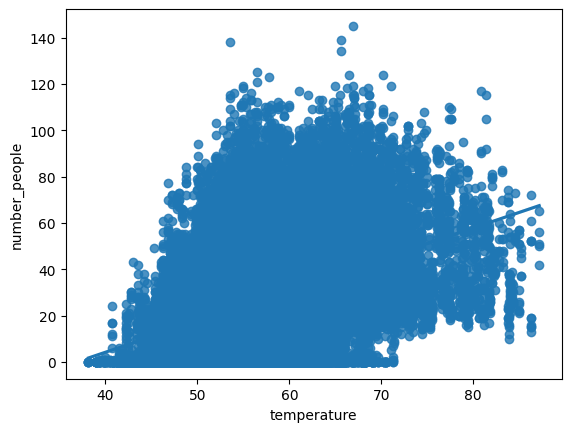

In [51]:
sns.regplot(data=df, x="temperature", y="number_people")
plt.show()

In [52]:
df.corr()

,number_people,timestamp,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
number_people,1.000000,0.550218,-0.162062,-0.173958,-0.048249,0.373327,0.182683,0.335350,-0.097854,0.552049,-0.322591
timestamp,0.550218,1.000000,-0.001793,-0.000509,0.002851,0.184849,0.009551,0.044676,-0.023221,0.999077,-0.077767
day_of_week,-0.162062,-0.001793,1.000000,0.791338,-0.075862,0.011169,-0.011782,-0.004824,0.015559,-0.001914,-0.021242
is_weekend,-0.173958,-0.000509,0.791338,1.000000,-0.031899,0.020673,-0.016646,-0.036127,0.008462,-0.000517,-0.021260
is_holiday,-0.048249,0.002851,-0.075862,-0.031899,1.000000,-0.088527,-0.014858,-0.070798,-0.094942,0.002843,0.121129
temperature,0.373327,0.184849,0.011169,0.020673,-0.088527,1.000000,0.093242,0.152476,0.063125,0.185121,-0.249638
is_start_of_semester,0.182683,0.009551,-0.011782,-0.016646,-0.014858,0.093242,1.000000,0.209862,-0.137160,0.010091,-0.015377
is_during_semester,0.335350,0.044676,-0.004824,-0.036127,-0.070798,0.152476,0.209862,1.000000,0.096556,0.045581,-0.124302
month,-0.097854,-0.023221,0.015559,0.008462,-0.094942,0.063125,-0.137160,0.096556,1.000000,-0.023624,-0.508552
hour,0.552049,0.999077,-0.001914,-0.000517,0.002843,0.185121,0.010091,0.045581,-0.023624,1.000000,-0.078816


In [53]:
df.drop(['timestamp'], axis=1, inplace=True)
df.head()

,number_people,day_of_week,is_weekend,is_holiday,temperature,is_start_of_semester,is_during_semester,month,hour,year
0,37,4,0,0,71.76,0,0,8,17,2015
1,45,4,0,0,71.76,0,0,8,17,2015
2,40,4,0,0,71.76,0,0,8,17,2015
3,44,4,0,0,71.76,0,0,8,17,2015
4,45,4,0,0,71.76,0,0,8,17,2015


In [54]:
X=df.drop("number_people", axis=1)
y=df["number_people"]

In [55]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=34)

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [57]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [58]:
def calculate_model_metrics(true, predicted):
    mse = mean_squared_error(true, predicted)
    r2 = r2_score(true, predicted)
    mae = mean_absolute_error(true, predicted)
    rmse= np.sqrt(mse)
    return mse, r2, mae, rmse

In [59]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "KNeighborsRegressor": KNeighborsRegressor(),
    "DecisionTreeRegressor": DecisionTreeRegressor(),
    "RandomForestRegressor": RandomForestRegressor()
}

In [64]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    mse_test, r2_test, mae_test, rmse_test = calculate_model_metrics(y_test, y_test_pred)
    mse_train, r2_train, mae_train, rmse_train = calculate_model_metrics(y_train, y_train_pred)

    print(f"Model: {list(models.values())[i]}")
    print(f"Test {list(models.keys())[i]}: R2={r2_test}, MSE={mse_test}, MAE={mae_test}, RMSE={rmse_test}")
    print(f"Train {list(models.keys())[i]}: R2={r2_train}, MSE={mse_train}, MAE={mae_train}, RMSE={rmse_train}")
    print("-" * 50)
    print("\n")

Model: LinearRegression()
Test LinearRegression: R2=0.6015534913229086, MSE=203.85473535629077, MAE=10.750964143750478, RMSE=14.277770671792245
Train LinearRegression: R2=0.599087540579178, MSE=206.79087483003724, MAE=10.738796097282897, RMSE=14.380225131410052
--------------------------------------------------


Model: Ridge()
Test Ridge: R2=0.6015535647570168, MSE=203.85469778564985, MAE=10.750974232542104, RMSE=14.27776935608815
Train Ridge: R2=0.5990875402652367, MSE=206.7908749919683, MAE=10.738804331547827, RMSE=14.38022513704039
--------------------------------------------------


Model: Lasso()
Test Lasso: R2=0.5872143698116202, MSE=211.19097185797466, MAE=10.963014629095067, RMSE=14.532411082059806
Train Lasso: R2=0.5853681638185326, MSE=213.86733717434865, MAE=10.944030016713064, RMSE=14.62420381334822
--------------------------------------------------


Model: KNeighborsRegressor()
Test KNeighborsRegressor: R2=0.9004291926738236, MSE=50.942799433938, MAE=4.8142416055577, RMS

In [66]:
#hyperparameter tuning for random forest regressor

knn_params = {
    "n_neighbors": [2, 3, 7, 9]}
random_forest_params = {
    "n_estimators": [100, 200,500,1000],
    "max_depth": [5,8, 10, 15,None],
    "max_features": ["sqrt", "log2", 5,7,10],
    "min_samples_split": [2,8,12,20]
}

In [67]:
from sklearn.model_selection import RandomizedSearchCV

randomcv_models=[
    ("KNN", KNeighborsRegressor(), knn_params),
    ("RandomForest", RandomForestRegressor(), random_forest_params)   
]

In [ ]:
for name, model, params in randomcv_models:
    random_search = RandomizedSearchCV(estimator=model, param_distributions=params, n_iter=100, cv=5, n_jobs=-1, random_state=3)
    random_search.fit(X_train_scaled, y_train)
    print(f"Best parameters for {name}: {random_search.best_params_}")

In [75]:
models = {
    "KNeighborsRegressor": KNeighborsRegressor(n_neighbors= 3),
    "RandomForestRegressor": RandomForestRegressor(n_estimators= 500, max_depth= None, max_features= 7, min_samples_split= 2)
}

In [76]:
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    mse_test, r2_test, mae_test, rmse_test = calculate_model_metrics(y_test, y_test_pred)
    mse_train, r2_train, mae_train, rmse_train = calculate_model_metrics(y_train, y_train_pred)

    print(f"Model: {list(models.values())[i]}")
    print(f"Test {list(models.keys())[i]}: R2={r2_test}, MSE={mse_test}, MAE={mae_test}, RMSE={rmse_test}")
    print(f"Train {list(models.keys())[i]}: R2={r2_train}, MSE={mse_train}, MAE={mae_train}, RMSE={rmse_train}")
    print("-" * 50)
    print("\n")

Model: KNeighborsRegressor(n_neighbors=3)
Test KNeighborsRegressor: R2=0.913042362924828, MSE=44.48960075474935, MAE=4.522020669840045, RMSE=6.6700525301341775
Train KNeighborsRegressor: R2=0.94847984728258, MSE=26.57412410480724, MAE=3.4234744200008578, RMSE=5.1550096124844655
--------------------------------------------------


Model: RandomForestRegressor(max_features=7, n_estimators=500)
Test RandomForestRegressor: R2=0.9245709116292536, MSE=38.59132032311576, MAE=4.257222829459257, RMSE=6.21219126581883
Train RandomForestRegressor: R2=0.9560739199451351, MSE=22.65709710175199, MAE=3.214840245276706, RMSE=4.759947174260654
--------------------------------------------------


